# Model Training

In [1]:
import os

import tensorflow as tf
import keras
from keras import Sequential
from keras.layers import Dense
import matplotlib.pyplot as plt

from dataclasses import dataclass

keras.__version__

'3.11.3'

## Model Training [20 Points]

All training parameters are defined here. So, this is where you can improve your accuracy and also the architecture.

Here are a few hints on to improve the accuracy:
- Train for a longer duration
- Try with different learning rates
- Try increasing the number of nodes/units in the Dense layers

You need to achieve **at least 85% accuracy** on the **test data** in order to score **10 points**. If you achieve **more than 89% test accuracy**, you end up with a full **20 points**.

In [2]:
is_training = True

In [3]:
@dataclass
class TrainingConfiguration:
    """
    Describes configuration of the training process
    """

    # batch_size: int = 32
    # epochs_count: int = 2
    # learning_rate: float = 0.1

    # update changed parameters in the below coding block.
    batch_size: int = 500
    epochs_count: int = 13
    learning_rate: float = 0.003

    ###
    ### YOUR CODE HERE
    ###

### 1.1 Model Definition

You need to define your model here. Recall that each image in the dataset has a size of `28 x 28`, so your `input_shape` should have a size of: `(28,28)`. Also, don’t forget, you need to implement a very simple MLP here, with only a few `Dense` layers. Have a look at this block diagram representing a simple MLP. 

<img src = "https://learnopencv.com/wp-content/uploads/2022/02/c4_02_mlps_fashion_mnist.png" width=950 align='center'><br/>

The time required to train your model on the course site should be roughly **2-3 minutes**.


**Note: Remember to use a `softmax` activation for the output layer.**

/Users/tapasyagutta/workspace/deep-learning/.tkVenv/lib/python3.12/site-packages/nbformat/__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)
(60000, 28, 28)
(10000, 28, 28)
4


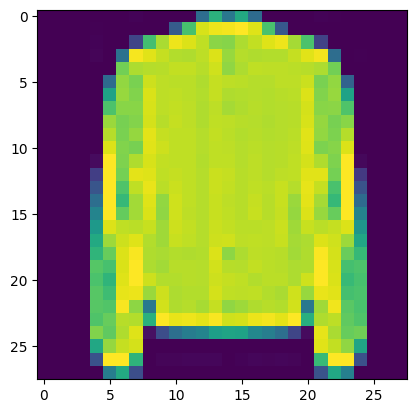

In [4]:
%run -i data.ipynb

In [5]:
def get_model():
    """
    You need to define your MLP model here.
    """

    model = Sequential()
    # model.add(keras.Input(shape=(784,)))
    model.add(keras.layers.Flatten(input_shape=(28, 28)))
    # model.add(Dense(128, activation=tf.nn.relu))
    model.add(Dense(512, activation="relu"))
    model.add(Dense(256, activation="relu"))
    model.add(Dense(128, activation="relu"))
    # model.add(Dense(10, activation=tf.nn.softmax))
    model.add(Dense(10, activation="softmax"))

    ###
    ### YOUR CODE HERE
    ###

    return model

### 1.2 Display the model

In [6]:
tf.random.set_seed(42)

model_fmnist = get_model()

print(model_fmnist.summary())

/Users/tapasyagutta/workspace/deep-learning/.tkVenv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

None


### 1.3 Create directory to save final model

In [7]:
if not os.path.exists("models"):
    os.makedirs("models")

### 1.4 Main

Let’s use the configuration parameters defined above and start training.

In [8]:
def compile_and_train_model(train_set, test_set, model, training_configuration):

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=training_configuration.learning_rate
        ),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=["accuracy"],
    )

    checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
        "./models/fashion_mnist_final_500_13_0025_4layers.h5",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
    )

    history = model.fit(
        train_set[0],
        train_set[1],
        batch_size=training_configuration.batch_size,
        epochs=training_configuration.epochs_count,
        validation_data=test_set,
        callbacks=[
            checkpoint_callback,
        ],
    )

    return model, history

In [9]:
###
### AUTOGRADER TEST - DO NOT REMOVE
###

In [10]:
###
### AUTOGRADER TEST - DO NOT REMOVE
###

### 1.5 Start training

In [11]:
training_configuration = TrainingConfiguration()

train_set = (X_train, y_train)
test_set = (X_test, y_test)

if is_training:
    model_final, training_results = compile_and_train_model(
        train_set, test_set, model_fmnist, training_configuration
    )

Epoch 1/13
113/120 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6818 - loss: 0.8766

120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7877 - loss: 0.5853 - val_accuracy: 0.8480 - val_loss: 0.4305
Epoch 2/13
111/120 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8617 - loss: 0.3851

120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8648 - loss: 0.3713 - val_accuracy: 0.8577 - val_loss: 0.3884
Epoch 3/13
116/120 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8775 - loss: 0.3340

120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8802 - loss: 0.3279 - val_accuracy: 0.8714 - val_loss: 0.3581
Epoch 4/13
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8858 - loss: 0.3072 - val_accuracy: 0.8670 - val_loss: 0.3637
Epoch 5/13
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8915 - loss: 0.2908 - val_accuracy: 0.8679 - val_loss: 0.3691
Epoch 6/13
111/120 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8946 - loss: 0.2761

120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8977 - loss: 0.2738 - val_accuracy: 0.8728 - val_loss: 0.3595
Epoch 7/13
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9015 - loss: 0.2639 - val_accuracy: 0.8710 - val_loss: 0.3644
Epoch 8/13
117/120 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9036 - loss: 0.2524

120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9051 - loss: 0.2504 - val_accuracy: 0.8772 - val_loss: 0.3471
Epoch 9/13
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9088 - loss: 0.2432 - val_accuracy: 0.8743 - val_loss: 0.3606
Epoch 10/13
114/120 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9081 - loss: 0.2396

120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9093 - loss: 0.2362 - val_accuracy: 0.8801 - val_loss: 0.3465
Epoch 11/13
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9137 - loss: 0.2278 - val_accuracy: 0.8791 - val_loss: 0.3498
Epoch 12/13
115/120 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9150 - loss: 0.2253

120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9138 - loss: 0.2259 - val_accuracy: 0.8832 - val_loss: 0.3514
Epoch 13/13
113/120 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9189 - loss: 0.2117

120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9171 - loss: 0.2166 - val_accuracy: 0.8848 - val_loss: 0.3480


### 1.7 Plot Loss

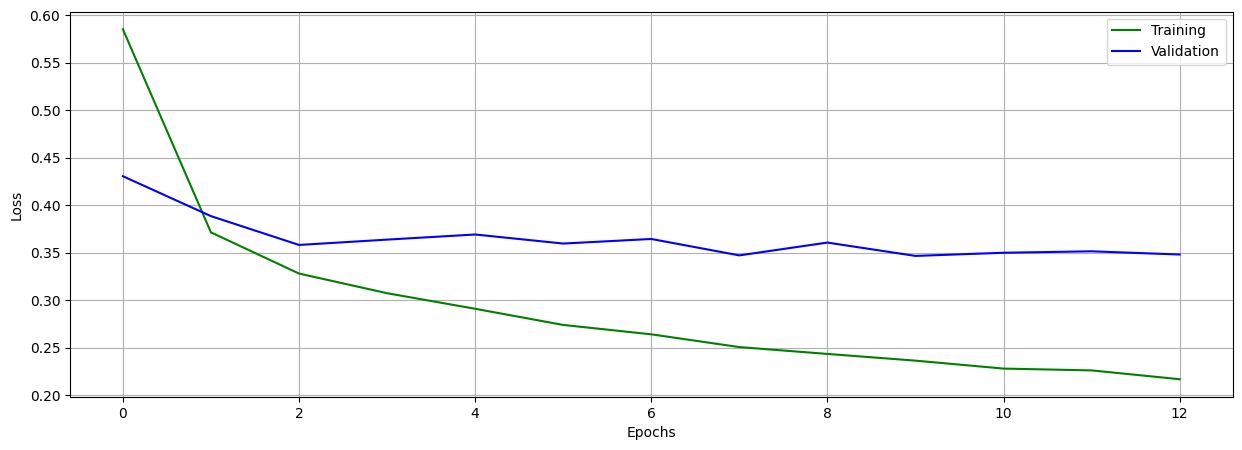

In [12]:
plt.figure(figsize=[15, 5])
plt.plot(training_results.history["loss"], "g")
plt.plot(training_results.history["val_loss"], "b")

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend(["Training", "Validation"], loc="upper right")
plt.grid(True)

### 1.7 Plot Accuracy

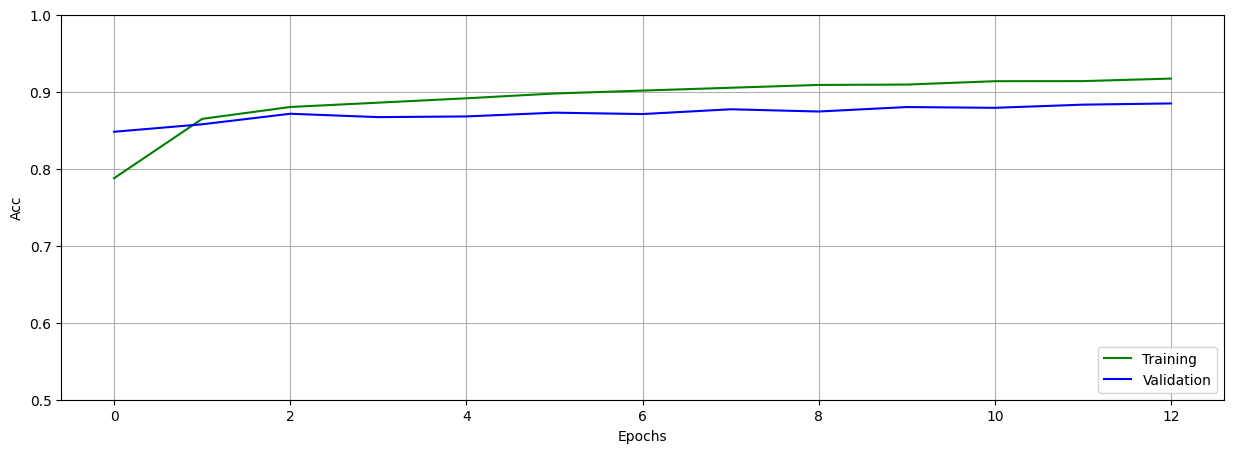

In [13]:
plt.figure(figsize=[15, 5])
plt.plot(training_results.history["accuracy"], "g")
plt.plot(training_results.history["val_accuracy"], "b")

plt.ylim([0.5, 1])

plt.xlabel("Epochs")
plt.ylabel("Acc")

plt.legend(["Training", "Validation"], loc="lower right")
plt.grid(True)